<a href="https://colab.research.google.com/github/HakkinDavid/lane-locator/blob/main/EDA/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA

Como parte de nuestro proyecto del segundo parcial de Inteligencia Computacional realizaremos detección de carriles y objetos en vialidades, en este caso a diferencia de proyectos similares es que utilizamos un dataset de imágenes de LATAM, por lo que lo carriles, lineas y el camino en muchas ocasiones tiene desperfectos los cuales deben ser contemplados en caso de que se desee implementar un sistema de autopiloto como en disintos EVs, evitando daños mayores al vehículo y sobretodo a la suspensión de este mismo

El dataset usado se llama Cracks and potholes el cual contiene mas de 11,000 imágenes de carretera en Brasil, donde se pueden contemplar distintos desperfectos que existen en esta

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()

if (PROJECT_ROOT / "Dataset").is_dir():
    DATA_ROOT = PROJECT_ROOT / "Dataset"
elif (PROJECT_ROOT.parent / "Dataset").is_dir():
    DATA_ROOT = PROJECT_ROOT.parent / "Dataset"
else:
    raise FileNotFoundError("Expected Dataset folder in the current directory or its parent.")

CULANE_FORMATTED_ROOT = DATA_ROOT / "CULane_formateado"

print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"CULane_formateado root: {CULANE_FORMATTED_ROOT.resolve()} | exists={CULANE_FORMATTED_ROOT.is_dir()}")

Dataset root: C:\Users\Rafael\Documents\GitHub\lane-locator\Dataset
CULane_formateado root: C:\Users\Rafael\Documents\GitHub\lane-locator\Dataset\CULane_formateado | exists=True


In [2]:
def load_v1_index(root: Path, culane_root=None) -> pd.DataFrame:
    rows = []

    carpetas = [p for p in sorted(root.iterdir()) if p.is_dir()]

    if culane_root is not None and culane_root.is_dir():
        carpetas.extend([p for p in sorted(culane_root.iterdir()) if p.is_dir()])

    def buscar_archivo(folder, patrones):
        for patron in patrones:
            archivo = next(folder.glob(patron), None)
            if archivo is not None:
                return archivo
        return None

    for folder in carpetas:
        raw = buscar_archivo(folder, ["*_RAW.jpg", "*_RAW.jpeg", "*_RAW.png", "raw.jpg", "raw.jpeg", "raw.png"])
        crack = buscar_archivo(folder, ["*_CRACK.png", "*_CRACK.jpg", "crack.png", "crack.jpg"])
        lane = buscar_archivo(folder, ["*_LANE.png", "*_LANE.jpg", "lane.png", "lane.jpg"])
        pothole = buscar_archivo(folder, ["*_POTHOLE.png", "*_POTHOLE.jpg", "pothhole.png", "pothhole.jpg"])

        if raw is None and crack is None and lane is None and pothole is None:
            continue

        rows.append(
            {
                "sample_id": folder.name,
                "folder": str(folder),
                "raw": str(raw) if raw else None,
                "crack_mask": str(crack) if crack else None,
                "lane_mask": str(lane) if lane else None,
                "pothole_mask": str(pothole) if pothole else None,
            }
        )

    return pd.DataFrame(rows)

df = load_v1_index(DATA_ROOT, CULANE_FORMATTED_ROOT)
df.head()

,sample_id,folder,raw,crack_mask,lane_mask,pothole_mask
0,1007599_RS_386_386RS289112_28920,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...
1,1007600_RS_386_386RS289112_28925,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...
2,1007607_RS_386_386RS289112_28960,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...
3,1007608_RS_386_386RS289112_28966,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...
4,1008367_RS_386_386RS289112_32760,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...,C:\Users\Rafael\Documents\GitHub\lane-locator\...


In [3]:
print(f"Samples: {len(df):,}")
print("Missing files per column:")
print(df[["raw", "crack_mask", "lane_mask", "pothole_mask"]].isna().sum())

Samples: 63,147
Missing files per column:
raw             1
crack_mask      0
lane_mask       0
pothole_mask    0
dtype: int64


In [4]:
def file_kb(p):
    if pd.isna(p):
        return None

    p = Path(p)

    if not p.exists():
        return None

    return p.stat().st_size / 1024.0


for col in ["raw", "crack_mask", "lane_mask", "pothole_mask"]:
    s = df[col].map(file_kb)
    df[f"{col}_kb"] = s
    print(f"{col} (KB): min={s.min():.1f}  median={s.median():.1f}  max={s.max():.1f}")

raw (KB): min=60.0  median=302.1  max=571.2
crack_mask (KB): min=2.9  median=11.4  max=31.0
lane_mask (KB): min=6.3  median=20.3  max=36.9
pothole_mask (KB): min=2.9  median=11.4  max=11.4


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63147 entries, 0 to 63146
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        63147 non-null  str    
 1   folder           63147 non-null  str    
 2   raw              63146 non-null  str    
 3   crack_mask       63147 non-null  str    
 4   lane_mask        63147 non-null  str    
 5   pothole_mask     63147 non-null  str    
 6   raw_kb           63146 non-null  float64
 7   crack_mask_kb    63147 non-null  float64
 8   lane_mask_kb     63147 non-null  float64
 9   pothole_mask_kb  63147 non-null  float64
dtypes: float64(4), str(6)
memory usage: 4.8 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
raw_kb,63146.0,297.230393,82.503386,60.028320,239.874268,302.090820,355.181641,571.208008
crack_mask_kb,63147.0,11.418855,0.533938,2.920898,11.435547,11.435547,11.435547,31.046875
lane_mask_kb,63147.0,19.916812,2.270841,6.347656,18.341797,20.278320,21.295898,36.949219
pothole_mask_kb,63147.0,11.373544,0.714156,2.920898,11.435547,11.435547,11.435547,11.435547


In [7]:
import numpy as np
from IPython.display import display
from PIL import Image


def im_size(path):
    if pd.isna(path):
        return (np.nan, np.nan)
    with Image.open(path) as im:
        return im.size


wh = df["raw"].map(im_size)
df["width"] = wh.map(lambda t: t[0])
df["height"] = wh.map(lambda t: t[1])
print("RAW width / height:")
display(df[["width", "height"]].describe())


def mask_fg_ratio(path):
    if pd.isna(path):
        return np.nan
    arr = np.asarray(Image.open(path).convert("L"))
    return float((arr > 0).mean())


for name, col in [("crack", "crack_mask"), ("lane", "lane_mask"), ("pothole", "pothole_mask")]:
    r = df[col].map(mask_fg_ratio)
    df[f"{name}_fg_ratio"] = r
    print(f"\n{name} mask — foreground fraction:")
    display(r.describe())


df_chk = df.dropna(subset=["raw", "crack_mask", "lane_mask", "pothole_mask"]).copy()
chk = df_chk.sample(
    n=min(100, len(df_chk)),
    random_state=0
)
mismatch = 0
for _, r in chk.iterrows():
    rw, rh = im_size(r["raw"])
    for col in ["crack_mask", "lane_mask", "pothole_mask"]:
        mw, mh = im_size(r[col])
        if (rw, rh) != (mw, mh):
            mismatch += 1
print(f"Size mismatches in {len(chk)} random rows: {mismatch}")

RAW width / height:


,width,height
count,63146.000000,63146.000000
mean,1635.385804,590.356000
std,53.114013,4.114901
min,1024.000000,590.000000
25%,1640.000000,590.000000
50%,1640.000000,590.000000
75%,1640.000000,590.000000
max,1640.000000,640.000000



crack mask — foreground fraction:


count    63147.000000
mean         0.000069
std          0.001180
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.050937
Name: crack_mask, dtype: float64


lane mask — foreground fraction:


count    63147.000000
mean         0.124899
std          0.059399
min          0.006014
25%          0.077876
50%          0.129405
75%          0.154517
max          0.635011
Name: lane_mask, dtype: float64


pothole mask — foreground fraction:


count    63147.000000
mean         0.000024
std          0.000973
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.093935
Name: pothole_mask, dtype: float64

Size mismatches in 100 random rows: 0


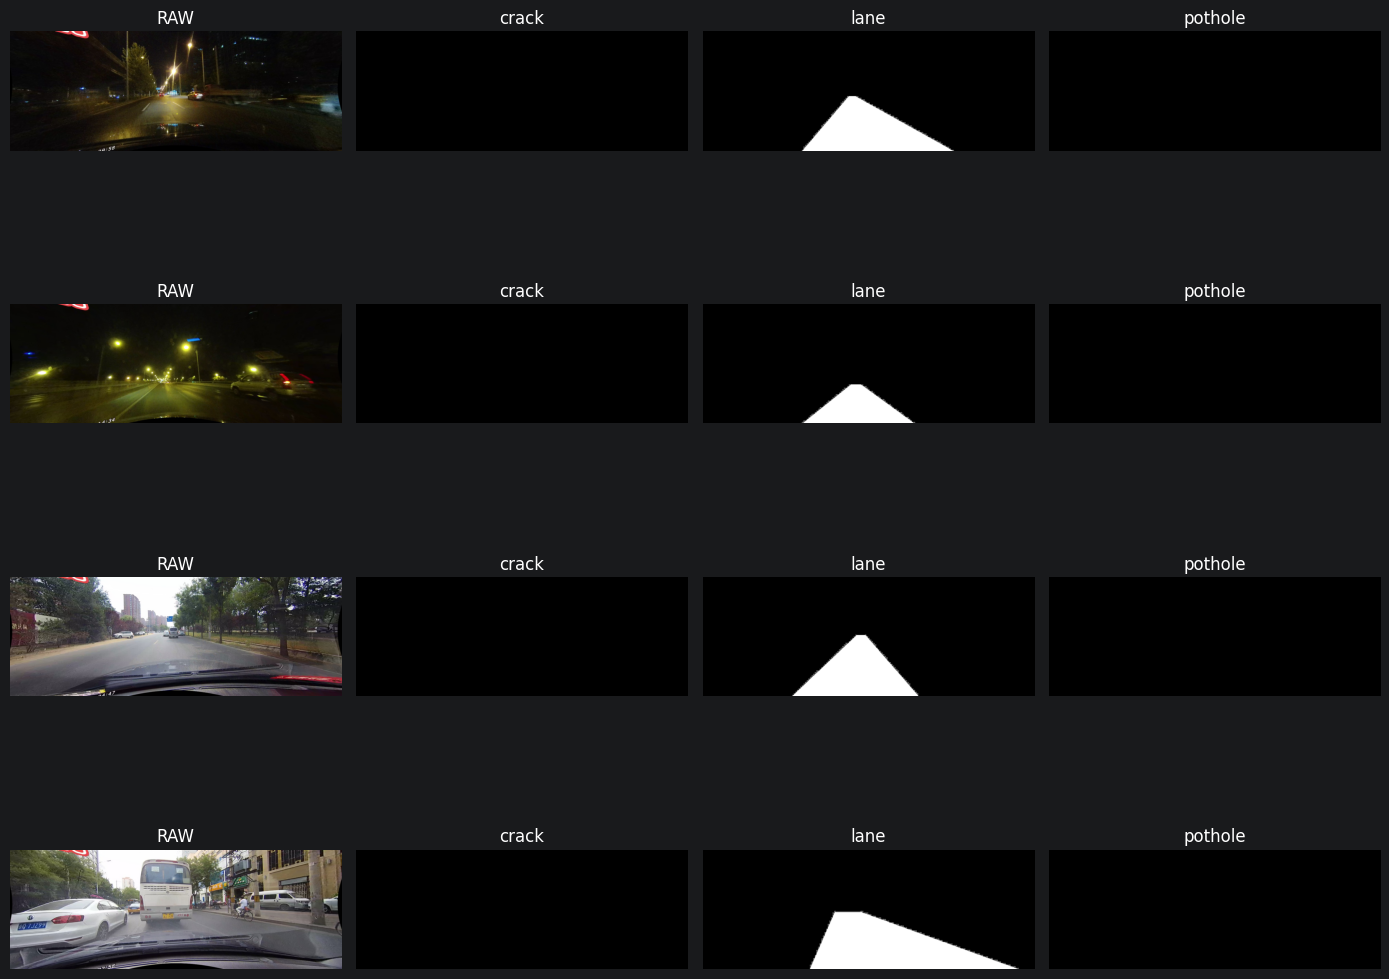

In [8]:
import matplotlib.pyplot as plt

df_plot = df.dropna(subset=["raw", "crack_mask", "lane_mask", "pothole_mask"]).copy()

if len(df_plot) == 0:
    raise ValueError("No complete rows available to plot.")

rng = np.random.default_rng(0)
pick = rng.choice(len(df_plot), size=min(4, len(df_plot)), replace=False)
fig, axes = plt.subplots(len(pick), 4, figsize=(14, 3 * len(pick)))
if len(pick) == 1:
    axes = np.expand_dims(axes, 0)
for row, i in enumerate(pick):
    r = df_plot.iloc[int(i)]
    raw = np.asarray(Image.open(r["raw"]).convert("RGB"))
    axes[row, 0].imshow(raw)
    axes[row, 0].set_title("RAW")
    axes[row, 0].axis("off")
    for j, (title, col) in enumerate(
        [("crack", "crack_mask"), ("lane", "lane_mask"), ("pothole", "pothole_mask")],
        start=1,
    ):
        m = np.asarray(Image.open(r[col]).convert("L"))
        axes[row, j].imshow(m > 0, cmap="gray")
        axes[row, j].set_title(title)
        axes[row, j].axis("off")
plt.tight_layout()
plt.show()

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
raw_kb,63146.0,297.230393,82.503386,60.028320,239.874268,302.090820,355.181641,571.208008
crack_mask_kb,63147.0,11.418855,0.533938,2.920898,11.435547,11.435547,11.435547,31.046875
lane_mask_kb,63147.0,19.916812,2.270841,6.347656,18.341797,20.278320,21.295898,36.949219
pothole_mask_kb,63147.0,11.373544,0.714156,2.920898,11.435547,11.435547,11.435547,11.435547
width,63146.0,1635.385804,53.114013,1024.000000,1640.000000,1640.000000,1640.000000,1640.000000
height,63146.0,590.356000,4.114901,590.000000,590.000000,590.000000,590.000000,640.000000
crack_fg_ratio,63147.0,0.000069,0.001180,0.000000,0.000000,0.000000,0.000000,0.050937
lane_fg_ratio,63147.0,0.124899,0.059399,0.006014,0.077876,0.129405,0.154517,0.635011
pothole_fg_ratio,63147.0,0.000024,0.000973,0.000000,0.000000,0.000000,0.000000,0.093935


## EDA por clase

In [10]:


import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from scipy import ndimage as ndi
from tqdm.auto import tqdm

need_base = ["sample_id", "raw", "crack_mask", "lane_mask", "pothole_mask"]
miss = [c for c in need_base if c not in df.columns]
if miss:
    raise RuntimeError("Faltan columnas en df: " + ", ".join(miss))

if "tipo_captura" not in df.columns:
    parts = df["sample_id"].str.split("_", n=3, expand=True)
    df["tipo_captura"] = parts[1]


def connected_components_stats(binary: np.ndarray) -> tuple[int, int, float, float]:
    fg = int(binary.sum())
    if fg == 0:
        return 0, 0, np.nan, np.nan
    labels, nlab = ndi.label(binary)
    if nlab == 0:
        return 0, fg, np.nan, np.nan
    sizes = np.bincount(labels.ravel())
    areas = sizes[1:]
    largest = int(areas.max())
    med = float(np.median(areas))
    largest_frac = largest / fg
    return int(nlab), fg, med, largest_frac


rows_long: list[dict] = []
overlap_rows: list[dict] = []

for _, r in tqdm(df.iterrows(), total=len(df), desc="EDA por clase"):
    sid = r["sample_id"]
    try:
        gray = np.asarray(Image.open(r["raw"]).convert("RGB"), dtype=np.float32).mean(axis=2)
        masks = {
            "crack": np.asarray(Image.open(r["crack_mask"]).convert("L")) > 0,
            "lane": np.asarray(Image.open(r["lane_mask"]).convert("L")) > 0,
            "pothole": np.asarray(Image.open(r["pothole_mask"]).convert("L")) > 0,
        }

        c, l, p = masks["crack"], masks["lane"], masks["pothole"]
        union_cl = np.logical_or(c, l)
        union_cp = np.logical_or(c, p)
        union_lp = np.logical_or(l, p)
        overlap_rows.append(
            {
                "sample_id": sid,
                "tipo_captura": r["tipo_captura"],
                "pair_crack_lane_inter": float(np.logical_and(c, l).mean()),
                "pair_crack_pothole_inter": float(np.logical_and(c, p).mean()),
                "pair_lane_pothole_inter": float(np.logical_and(l, p).mean()),
                "triple_inter": float(np.logical_and(np.logical_and(c, l), p).mean()),
                "iou_crack_lane": float(np.logical_and(c, l).sum() / union_cl.sum()) if union_cl.any() else 0.0,
                "iou_crack_pothole": float(np.logical_and(c, p).sum() / union_cp.sum()) if union_cp.any() else 0.0,
                "iou_lane_pothole": float(np.logical_and(l, p).sum() / union_lp.sum()) if union_lp.any() else 0.0,
            }
        )

        for cls_name, bin_mask in masks.items():
            n_cc, fg_px, cc_area_median, largest_frac = connected_components_stats(bin_mask)
            total_px = bin_mask.size
            fg_ratio = fg_px / total_px if total_px else 0.0
            empty = fg_px == 0

            mean_fg = np.nan
            std_fg = np.nan
            mean_bg = np.nan
            contrast = np.nan
            if not empty:
                vals = gray[bin_mask]
                bg = gray[~bin_mask]
                mean_fg = float(vals.mean())
                std_fg = float(vals.std())
                mean_bg = float(bg.mean())
                contrast = mean_fg - mean_bg

            rows_long.append(
                {
                    "sample_id": sid,
                    "tipo_captura": r["tipo_captura"],
                    "class": cls_name,
                    "fg_ratio": fg_ratio,
                    "fg_pixels": fg_px,
                    "empty_mask": empty,
                    "n_connected_components": n_cc,
                    "cc_area_median": cc_area_median,
                    "largest_cc_fg_fraction": largest_frac,
                    "gray_mean_fg": mean_fg,
                    "gray_std_fg": std_fg,
                    "gray_mean_bg": mean_bg,
                    "gray_contrast_fg_minus_bg": contrast,
                }
            )
    except Exception as e:
        warnings.warn(f"Muestra omitida {sid}: {e}")

eda_long = pd.DataFrame(rows_long)
eda_overlap = pd.DataFrame(overlap_rows)

print("Filas long-format (3 por muestra):", len(eda_long))
display(eda_long.groupby("class").agg(
    muestras=("sample_id", "nunique"),
    pct_mascara_vacia=("empty_mask", lambda s: 100 * s.mean()),
    fg_ratio=("fg_ratio", "median"),
    fg_ratio_p90=("fg_ratio", lambda s: s.quantile(0.9)),
    n_cc_mediana=("n_connected_components", "median"),
    n_cc_p90=("n_connected_components", lambda s: s.quantile(0.9)),
    mayor_cc_frac_fg_mediana=("largest_cc_fg_fraction", "median"),
    contraste_gris_mediana=("gray_contrast_fg_minus_bg", "median"),
).round(4))

print("\nSolapamiento entre clases (medianas en fracción de imagen / IoU):")
display(eda_overlap.drop(columns=["sample_id"]).groupby("tipo_captura").median(numeric_only=True).round(5))
print("Global (todas las muestras):")
display(eda_overlap.drop(columns=["sample_id"]).median(numeric_only=True).round(5))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from scipy import ndimage as ndi
from tqdm.auto import tqdm

need_base = ["sample_id", "raw", "crack_mask", "lane_mask", "pothole_mask"]
miss = [c for c in need_base if c not in df.columns]
if miss:
    raise RuntimeError("Faltan columnas en df: " + ", ".join(miss))

if "tipo_captura" not in df.columns:
    parts = df["sample_id"].str.split("_", n=3, expand=True)
    df["tipo_captura"] = parts[1]


def connected_components_stats(binary: np.ndarray) -> tuple[int, int, float, float]:
    fg = int(binary.sum())
    if fg == 0:
        return 0, 0, np.nan, np.nan
    labels, nlab = ndi.label(binary)
    if nlab == 0:
        return 0, fg, np.nan, np.nan
    sizes = np.bincount(labels.ravel())
    areas = sizes[1:]
    largest = int(areas.max())
    med = float(np.median(areas))
    largest_frac = largest / fg
    return int(nlab), fg, med, largest_frac


rows_long: list[dict] = []
overlap_rows: list[dict] = []

for _, r in tqdm(df.iterrows(), total=len(df), desc="EDA por clase"):
    sid = r["sample_id"]
    try:
        gray = np.asarray(Image.open(r["raw"]).convert("RGB"), dtype=np.float32).mean(axis=2)
        masks = {
            "crack": np.asarray(Image.open(r["crack_mask"]).convert("L")) > 0,
            "lane": np.asarray(Image.open(r["lane_mask"]).convert("L")) > 0,
            "pothole": np.asarray(Image.open(r["pothole_mask"]).convert("L")) > 0,
        }

        c, l, p = masks["crack"], masks["lane"], masks["pothole"]
        union_cl = np.logical_or(c, l)
        union_cp = np.logical_or(c, p)
        union_lp = np.logical_or(l, p)
        overlap_rows.append(
            {
                "sample_id": sid,
                "tipo_captura": r["tipo_captura"],
                "pair_crack_lane_inter": float(np.logical_and(c, l).mean()),
                "pair_crack_pothole_inter": float(np.logical_and(c, p).mean()),
                "pair_lane_pothole_inter": float(np.logical_and(l, p).mean()),
                "triple_inter": float(np.logical_and(np.logical_and(c, l), p).mean()),
                "iou_crack_lane": float(np.logical_and(c, l).sum() / union_cl.sum()) if union_cl.any() else 0.0,
                "iou_crack_pothole": float(np.logical_and(c, p).sum() / union_cp.sum()) if union_cp.any() else 0.0,
                "iou_lane_pothole": float(np.logical_and(l, p).sum() / union_lp.sum()) if union_lp.any() else 0.0,
            }
        )

        for cls_name, bin_mask in masks.items():
            n_cc, fg_px, cc_area_median, largest_frac = connected_components_stats(bin_mask)
            total_px = bin_mask.size
            fg_ratio = fg_px / total_px if total_px else 0.0
            empty = fg_px == 0

            mean_fg = np.nan
            std_fg = np.nan
            mean_bg = np.nan
            contrast = np.nan
            if not empty:
                vals = gray[bin_mask]
                bg = gray[~bin_mask]
                mean_fg = float(vals.mean())
                std_fg = float(vals.std())
                mean_bg = float(bg.mean())
                contrast = mean_fg - mean_bg

            rows_long.append(
                {
                    "sample_id": sid,
                    "tipo_captura": r["tipo_captura"],
                    "class": cls_name,
                    "fg_ratio": fg_ratio,
                    "fg_pixels": fg_px,
                    "empty_mask": empty,
                    "n_connected_components": n_cc,
                    "cc_area_median": cc_area_median,
                    "largest_cc_fg_fraction": largest_frac,
                    "gray_mean_fg": mean_fg,
                    "gray_std_fg": std_fg,
                    "gray_mean_bg": mean_bg,
                    "gray_contrast_fg_minus_bg": contrast,
                }
            )
    except Exception as e:
        warnings.warn(f"Muestra omitida {sid}: {e}")

eda_long = pd.DataFrame(rows_long)
eda_overlap = pd.DataFrame(overlap_rows)

print("Filas long-format (3 por muestra):", len(eda_long))
display(eda_long.groupby("class").agg(
    muestras=("sample_id", "nunique"),
    pct_mascara_vacia=("empty_mask", lambda s: 100 * s.mean()),
    fg_ratio=("fg_ratio", "median"),
    fg_ratio_p90=("fg_ratio", lambda s: s.quantile(0.9)),
    n_cc_mediana=("n_connected_components", "median"),
    n_cc_p90=("n_connected_components", lambda s: s.quantile(0.9)),
    mayor_cc_frac_fg_mediana=("largest_cc_fg_fraction", "median"),
    contraste_gris_mediana=("gray_contrast_fg_minus_bg", "median"),
).round(4))

print("\nSolapamiento entre clases (medianas en fracción de imagen / IoU):")
display(eda_overlap.drop(columns=["sample_id"]).groupby("tipo_captura").median(numeric_only=True).round(5))
print("Global (todas las muestras):")
display(eda_overlap.drop(columns=["sample_id"]).median(numeric_only=True).round(5))

EDA por clase:   0%|          | 0/63147 [00:00<?, ?it/s]

C:\Users\Rafael\AppData\Local\Temp\ipykernel_28940\3033856173.py:103: UserWarning: Muestra omitida 1058798_DF_010_010BDF0010_06135: 'float' object has no attribute 'read'
  warnings.warn(f"Muestra omitida {sid}: {e}")


KeyboardInterrupt: 

### Figuras por clase

Distribuciones de cobertura, fragmentacion y contraste gris

In [ ]:
numeric_cols = ["fg_ratio", "n_connected_components", "largest_cc_fg_fraction", "gray_contrast_fg_minus_bg"]
display(eda_long.groupby("class")[numeric_cols].describe().round(4))

wide_fg = eda_long.pivot_table(index="sample_id", columns="class", values="fg_ratio")
print("Correlación de fg_ratio entre clases (misma muestra):")
display(wide_fg.corr().round(3))

classes = ["crack", "lane", "pothole"]
colors = {"crack": "#8C564B", "lane": "#17BECF", "pothole": "#BCBD22"}

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for i, cls in enumerate(classes):
    sub = eda_long[eda_long["class"] == cls]
    axes[i, 0].hist(sub["fg_ratio"], bins=50, color=colors[cls], alpha=0.85, edgecolor="white")
    axes[i, 0].set_title(f"{cls}: fracción foreground")
    axes[i, 0].set_xlabel("fg_ratio")

    nn = sub.loc[~sub["empty_mask"], "n_connected_components"]
    if len(nn):
        axes[i, 1].hist(np.log1p(nn), bins=50, color=colors[cls], alpha=0.85, edgecolor="white")
    axes[i, 1].set_title(f"{cls}: log(1 + componentes conexas)")
    axes[i, 1].set_xlabel("log1p(n_cc)")

    ct = sub.loc[~sub["empty_mask"], "gray_contrast_fg_minus_bg"].dropna()
    if len(ct):
        axes[i, 2].hist(ct, bins=50, color=colors[cls], alpha=0.85, edgecolor="white")
    axes[i, 2].set_title(f"{cls}: contraste gris (fg − bg)")
    axes[i, 2].set_xlabel("contraste")

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 3, figsize=(14, 4))
for i, cls in enumerate(classes):
    sub = eda_long[eda_long["class"] == cls]
    cats = sorted(sub["tipo_captura"].dropna().unique())
    data = [sub.loc[sub["tipo_captura"] == c, "fg_ratio"].values for c in cats]
    ax2[i].boxplot(data, tick_labels=[str(c) for c in cats])
    ax2[i].set_title(f"{cls}: fg_ratio por tipo_captura")
    ax2[i].set_ylabel("fg_ratio")
plt.tight_layout()
plt.show()

In [ ]:
sample_cap = min(800, len(wide_fg))
rs = wide_fg.sample(n=sample_cap, random_state=0).dropna(how="any")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(rs["crack"], rs["lane"], s=6, alpha=0.35, c="#4C72B0")
axes[0].set_xlabel("crack fg_ratio")
axes[0].set_ylabel("lane fg_ratio")

axes[1].scatter(rs["crack"], rs["pothole"], s=6, alpha=0.35, c="#55A868")
axes[1].set_xlabel("crack fg_ratio")
axes[1].set_ylabel("pothole fg_ratio")

axes[2].scatter(rs["lane"], rs["pothole"], s=6, alpha=0.35, c="#C44E52")
axes[2].set_xlabel("lane fg_ratio")
axes[2].set_ylabel("pothole fg_ratio")

plt.suptitle(f"Pares de cobertura (n={len(rs)} muestras aleatorias)")
plt.tight_layout()
plt.show()

ov_numeric = eda_overlap.drop(columns=["sample_id", "tipo_captura"]).median(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 4))
cols_show = [c for c in ov_numeric.index if c.startswith("pair") or c.startswith("triple")]
ax.bar(cols_show, ov_numeric[cols_show].values, color="steelblue", edgecolor="white")
ax.set_title("Medianas de solapamiento (fracción de píxeles de la imagen)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()